In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 16
    E2E_BATCH_SIZE = 4
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [4]:
# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# TRAINING_CACHE_DIR = None
# VALIDATION_CACHE_DIR = None
TRAINING_CACHE_DIR = ".training_cache"
VALIDATION_CACHE_DIR = ".validation_cache"
NUM_TRAINING_TOKENS = int(1e5)
EVAL_INTERVAL = int(1e4)
NUM_VALIDATION_TOKENS = int(1e4)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1

# Train SAEs

In [8]:
from itertools import product

import numpy as np

from tiny_stories_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    InteractionEncoderConfig,
    ReluActivationFunctionConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from tiny_stories_sae.validation import run_validations


def SAE_SPECS():
    return product(TrainingMethod, (False, True))


empty_saes = {
    (method, use_interaction): {
        layer: SAE(
            SAEConfig(
                d_model=D_MODEL,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                encoder=EncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                )
                if not use_interaction
                else InteractionEncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                    n_interaction_iterations=1,
                ),
                decoder=DecoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                ),
            )
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
}


def linear_decay(frac_trained: float):
    return 1.0 - frac_trained


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        e2e_batch_size=E2E_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        finetune_lr_schedule=linear_decay,  # per Karvonen (2025)
        use_downstream_saes=method
        in (TrainingMethod.next_layer, TrainingMethod.next_layer_finetuned),
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}
validation_results = {}

In [6]:
import os

from tiny_stories_sae.training import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [9]:
spec = (TrainingMethod.standard, False)

# training_config[spec].train_layers = [0, 1, 2, 3]
training_config[spec].train_layers = [3]

training_results[spec] = train(
    model,
    tokenizer,
    empty_saes[spec],
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
    checkpoints_at=[int((1.0 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS)],
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    training_results[spec].final_saes,
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
    start_layer=3,
    end_layer=5,
)
print(
    f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
)
print(
    f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
)

Layer 3

  0%|          | 0/100000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/10000 [00:00<?, ?it/s]

mean rre={3: 0.7152608633041382})
mean kl={4: 1.914379358291626})


In [ ]:
spec = (TrainingMethod.finetuned, False)

# training_config[spec].train_layers = [0, 1, 2, 3]
training_config[spec].train_layers = [3]

training_results[spec] = fine_tune(
    model,
    tokenizer,
    training_results[(TrainingMethod.standard, False)],
    0,
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    training_results[spec].final_saes,
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
    start_layer=3,
    end_layer=5,
)
print(
    f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
)
print(
    f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
)

NameError: name 'checkpoint_index' is not defined

In [ ]:
spec = (TrainingMethod.next_layer, False)
training_config[spec].train_layers = [0, 1, 2, 3]

training_results[spec] = train(
    model,
    tokenizer,
    empty_saes[spec],
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    empty_saes[spec],
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
)
print(f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })")
print(f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })")

Layer 3

  0%|          | 0/100000 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/100000 [00:00<?, ?it/s]

Layer 1

  0%|          | 0/100000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/100000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/10000 [00:00<?, ?it/s]

mean rre={0: 0.3390534222126007, 1: 0.4563569128513336, 2: 0.6064233779907227, 3: 0.9163272976875305})
mean kl={4: 2.7759339809417725})


In [ ]:
spec = (TrainingMethod.e2e, False)
training_config[spec].train_layers = [0, 1, 2]# , 3]

training_results[spec] = train(
    model,
    tokenizer,
    empty_saes[spec],
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    empty_saes[spec],
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
)
print(f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })")
print(f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })")

Layer 2

  0%|          | 0/100000 [00:00<?, ?it/s]

needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]
needs replacement [3, 4]
orig replacement [2]


Layer 1

  0%|          | 0/100000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/100000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/10000 [00:00<?, ?it/s]

mean rre={0: 1.3465244770050049, 1: 1.6926268339157104, 2: 1.4175691604614258, 3: 1.0046234130859375})
mean kl={4: 3.6923861503601074})


In [ ]:
spec = (TrainingMethod.standard, True)
training_config[spec].train_layers = [0, 1, 2, 3]
# training_config[spec].train_layers = [3]
training_config[spec].interaction_lr = 1e-3
training_config[spec].num_train_tokens = NUM_TRAINING_TOKENS

training_results[spec] = train(
    model,
    tokenizer,
    empty_saes[spec],
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    empty_saes[spec],# {3: saes[spec][3]},
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
    # start_layer=3,
    # end_layer=5,
)
print(f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })")
print(f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })")

Layer 3

  0%|          | 0/100000 [00:00<?, ?it/s]

AttributeError: 'function' object has no attribute 'update'

In [29]:
np.append(np.empty((0,)), 5)

array([5.])

In [24]:
training_results[spec]

{0: defaultdict(list, {}),
 1: defaultdict(list, {}),
 2: defaultdict(list, {}),
 3: defaultdict(list, {})}

In [ ]:
spec = (TrainingMethod.next_layer, True)
# training_config[spec].train_layers = [0, 1, 2, 3]
training_config[spec].train_layers = [3]
training_config[spec].interaction_lr = 1e-3
training_config[spec].num_train_tokens = NUM_TRAINING_TOKENS

training_results[spec] = train(
    model,
    tokenizer,
    empty_saes[spec],
    training_dataset,
    training_config[spec],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,
)
validation_results[spec] = run_validations(
    model,
    tokenizer,
    empty_saes[spec],
    validation_dataset,
    num_tokens=NUM_VALIDATION_TOKENS,
    tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
    inference_batch_size=training_config[spec].training_batch_size,
    cache_dir=VALIDATION_CACHE_DIR,
)
print(f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })")
print(f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })")

Layer 3

  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

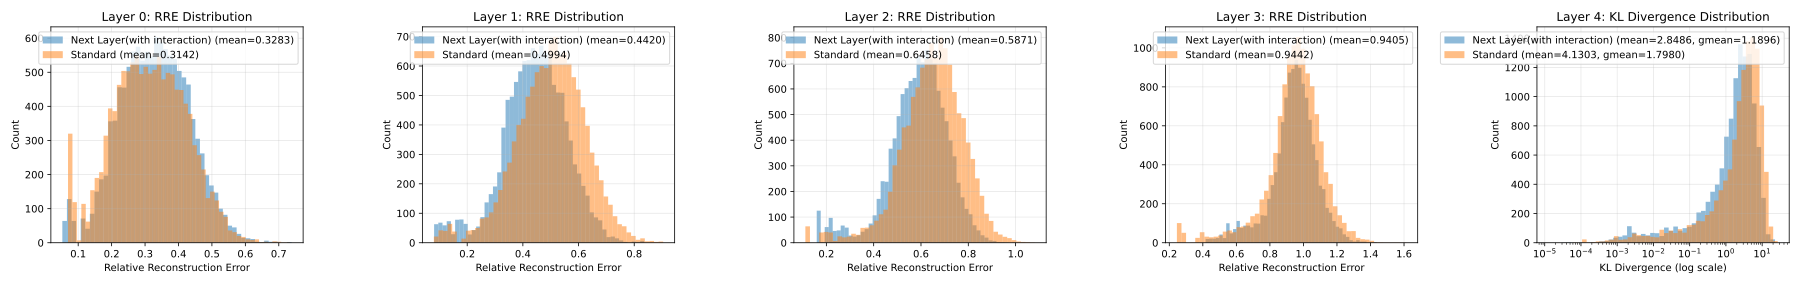

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gmean

from tiny_stories_sae.ops import current_plot_to_svg

# Collect all available layers across all specs
all_layers = set()
for spec in validation_results:
    if hasattr(validation_results[spec], 'layer_results'):
        all_layers.update(validation_results[spec].layer_results.keys())
all_layers = sorted(all_layers)

num_plots = len(all_layers)
fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 4))
if num_plots == 1:
    axes = [axes]

plot_idx = 0

for layer in range(0, model.config.num_layers):
    ax = axes[plot_idx]
    for spec in validation_results:
        if layer in validation_results[spec].layer_results:
            rre_values = validation_results[spec].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                ax.hist(
                    rre_values,
                    bins=50,
                    alpha=0.5,
                    label=f"{spec[0].value}{'(with interaction)' if spec[1] else ''} (mean={np.mean(rre_values):.4f})",
                )
    ax.set_xlabel("Relative Reconstruction Error")
    ax.set_ylabel("Count")
    ax.set_title(f"Layer {layer}: RRE Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# Plot KL for each layer that has it
for layer in [model.config.num_layers]:
    ax = axes[plot_idx]
    for spec in validation_results:
        if layer in validation_results[spec].layer_results:
            kl_values = validation_results[spec].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                # Filter out non-positive values for log scale
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    geom_mean = gmean(kl_positive)
                    ax.hist(
                        kl_positive,
                        bins=np.logspace(np.log10(kl_positive.min()), np.log10(kl_positive.max()), 50),
                        alpha=0.5,
                        label=f"{spec[0].value}{'(with interaction)' if spec[1] else ''} (mean={np.mean(kl_values):.4f}, gmean={geom_mean:.4f})",
                    )
    ax.set_xscale('log')
    ax.set_xlabel("KL Divergence (log scale)")
    ax.set_ylabel("Count")
    ax.set_title(f"Layer {layer}: KL Divergence Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plot_idx += 1

plt.tight_layout()
current_plot_to_svg()